# Preps

In [ ]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))
print(f"Project root: {PROJECT_ROOT}")

Project root: /Users/zeguru/Projects/AI/tiny-text-transformers


# Imports

In [24]:
import torch
import matplotlib.pyplot as plt
from src.infra.dataset.classification import TextClassificationDataset
from src.infra.dataset.autoregressive import AutoRegressiveDataset

from src.infra.tokenizer import CharacterTokenizer
from src.task.config import ModelConfig, TrainingConfig
from src.task.model import TinyClassifier
from src.task.model import TinyTransformerLM

from src.task.training.util import count_parameters, separator
from src.infra.dataset.util import split_tokens, get_batch


# Configs

In [25]:
generator_config = ModelConfig(context_length=128, d_model=128, d_ff=512, num_layers=4, number_of_heads=4)

training_config = TrainingConfig(
    batch_size=32,
    learning_rate=0.001,
    num_steps=10_000,
    eval_interval=1_000,
    eval_batches=100,
)

# Inspect

In [26]:
# Cell 3
print("Transformer configuration")
print("=" * 40)

print(f"context length : {model_config.context_length}")
print(f"d_model        : {model_config.d_model}")
print(f"d_ff           : {model_config.d_ff}")
print(f"layers         : {model_config.num_layers}")
print(f"heads          : {model_config.number_of_heads}")
print(f"dropout        : {model_config.dropout}")

Transformer configuration
context length : 128
d_model        : 128
d_ff           : 512
layers         : 4
heads          : 4
dropout        : 0.1


# Load Corpus

In [27]:

shakespear_corpus = "../data/tiny_shakespear.txt"
tinystories_corpus = "../data/tinystories_300k.txt"

checkpoint = "../checkpoints/mh_tiny_text_generator.pt"
shakespear_tokenizer = "../checkpoints/shakespeare_tokenizer.json"

tokenizer_path = Path(shakespear_tokenizer)
sp_data_path = Path(shakespear_corpus)
ts_data_path = Path(tinystories_corpus)

tokenizer = CharacterTokenizer.load(tokenizer_path)
print(f"Vocab size: {tokenizer.vocab_size}")

shakespear_text = sp_data_path.read_text(encoding="utf-8",)
tinystories_text = ts_data_path.read_text(encoding="utf-8",)

sp_text_length = len(shakespear_text)
print(f"Shakespear Characters: {sp_text_length:,}")

ts_text_length = len(tinystories_text)
print(f"Tiny Stories Characters: {ts_text_length:,}")


Vocab size: 67
Shakespear Characters: 1,115,394
Tiny Stories Characters: 299,987


# Load alternative dataset - experimental

In [28]:
# from datasets import load_dataset

# tiny_stories_ds = load_dataset("roneneldan/TinyStories", split="train", streaming=True,)

# # for story in tiny_stories_ds.take(3):
# #     print("=" * 80)
# #     print(story["text"])
    
# TARGET = 300_000
# chunks = []
# n = 0

# for row in ds:
#     story = row["text"].strip() + "\n"
    
#     if n + len(story) > TARGET:
#         break
    
#     chunks.append(story)
#     n += len(story)

# with open("../data/tinystories_300k.txt", "w", encoding="utf-8") as f:
#     f.write("".join(chunks))

# print(f"Characters: {n:,}")
# print(f"Stories: {len(chunks):,}")

# Inspect Corpus

## Identify UNKN


In [29]:
unknowns = sum(
    1
    for ch in tinystories_text
    if ch not in tokenizer.stoi
)

print(f"Unknown characters: {unknowns:,}")

Unknown characters: 2,496


## Verify

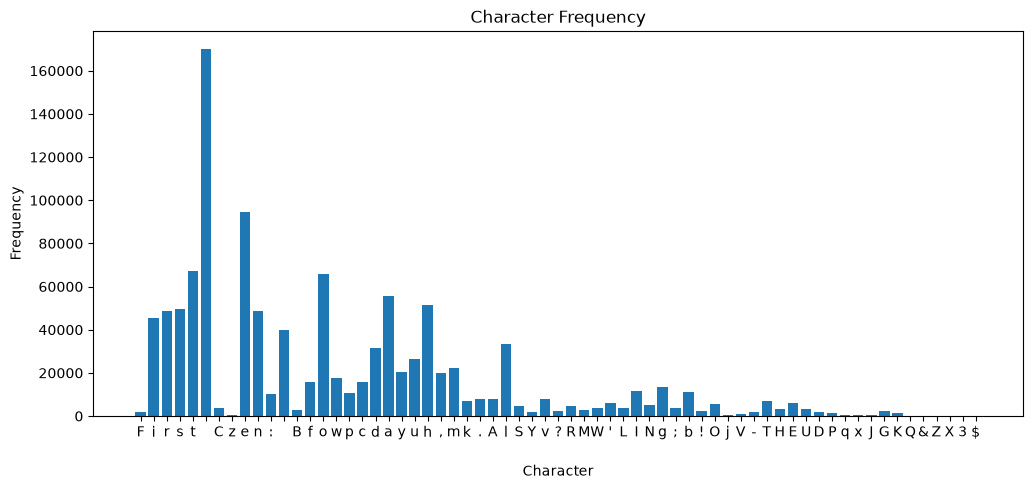

In [32]:
from collections import Counter

counts = Counter(shakespear_text)

characters = list(counts.keys())
frequencies = list(counts.values())

plt.figure(figsize=(12, 5))
plt.bar(characters, frequencies)

plt.title("Character Frequency")
plt.xlabel("Character")
plt.ylabel("Frequency")

plt.show()

# Tokens

In [33]:

shakespear_tokens = torch.tensor(
    tokenizer.encode(shakespear_text),
    dtype=torch.long,
    )

tinystories_tokens = torch.tensor(
    tokenizer.encode(tinystories_text),
    dtype=torch.long,
    )


# Datasets 

## Inorder to maintain shakespear style we use tinystories as extra training set

Shakespeare:

    90% train
     5% val
     5% test

TinyStories:

    100% train

In [41]:
shakespeare_train, shakespeare_val, shakespeare_test = split_tokens(
    shakespear_tokens,
    )

#Concat the entire tinystories to join shakespear train tokens
training_tokens = torch.cat([
    shakespeare_train,
    tinystories_tokens,
    ])

val_tokens  = shakespeare_val
test_tokens = shakespeare_test

train_dataset = AutoRegressiveDataset(
    tokens=training_tokens,
    context_length=model_config.context_length,
    )

val_dataset = AutoRegressiveDataset(
    tokens=val_tokens,
    context_length=model_config.context_length,
    )

test_dataset = AutoRegressiveDataset(
    tokens=test_tokens,
    context_length=model_config.context_length,
    )


x, y = train_dataset[0]

print("Context length:", len(x))
print()
separator("INPUT")
print(tokenizer.decode(x.tolist()))
separator("TARGET")
print(tokenizer.decode(y.tolist()))

Context length: 128



NameError: name 'separator' is not defined

# Model

At TinyTransformerLM
number of heads:  4
multi head
number of heads:  4
multi head
number of heads:  4
multi head
number of heads:  4
multi head
parameter count 825,155


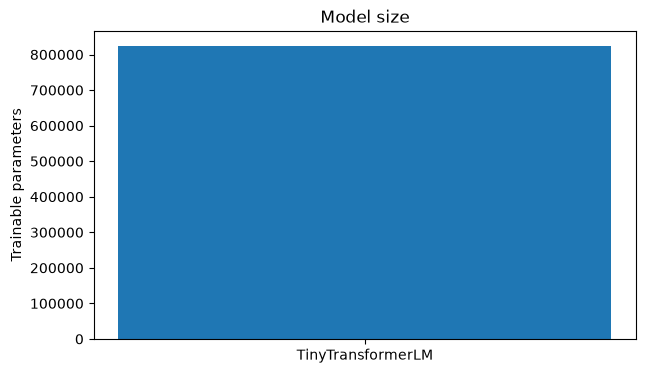

In [35]:
model = TinyTransformerLM(
    config=model_config,
    vocab_size=tokenizer.vocab_size,
    )

print("=" * 40)
parameter_count = count_parameters(model)
print(f"parameter count {parameter_count:,}")
print("=" * 40)

plt.figure(figsize=(7, 4))
plt.bar(["TinyTransformerLM"], [parameter_count])
plt.ylabel("Trainable parameters")
plt.title("Model size")
plt.show()

# Train

In [36]:
from src.task.training.autoregressive import train, evaluate

model, steps, train_history, val_history = train(
    model=model,
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    training_config=training_config,
    )

print("training complete")

step    0 | train 4.4590 | val 4.4587
step 1000 | train 1.6559 | val 1.7987
step 2000 | train 1.4659 | val 1.6299
step 3000 | train 1.3806 | val 1.5718
step 4000 | train 1.3278 | val 1.5283
step 5000 | train 1.3006 | val 1.4973
step 6000 | train 1.2823 | val 1.4797
step 7000 | train 1.2586 | val 1.4676
step 8000 | train 1.2427 | val 1.4670
step 9000 | train 1.2325 | val 1.4590
training complete


# Plot afterwards

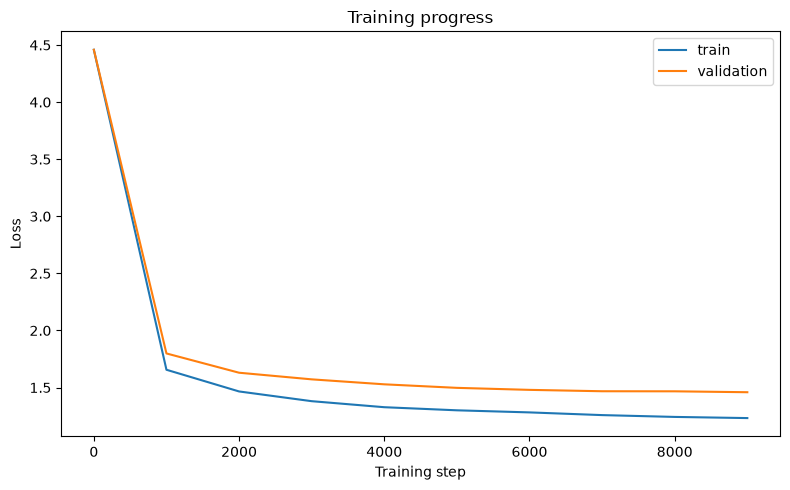

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    steps,
    train_history,
    label="train",
)

plt.plot(
    steps,
    val_history,
    label="validation",
)

plt.xlabel("Training step")
plt.ylabel("Loss")
plt.title("Training progress")
plt.legend()

plt.tight_layout()
plt.show()

# Save the Checkpoint

In [42]:
checkpoint_dir = Path("../checkpoints")
checkpoint_dir.mkdir(parents=True, exist_ok=True)

checkpoint_path = (
    checkpoint_dir / "tiny_poet.pt"
)

torch.save(
    model.state_dict(),
    checkpoint_path,
)

print(f"Saved {checkpoint_path}")

Saved ../checkpoints/tiny_poet.pt
